# EDA: Material Distribution Analysis by House Type
Analisis distribusi material (atap, dinding, lantai) dari field prediksi pada mkn_house_metadata.json, dipisah berdasarkan house_type (multi, single_exterior_only, single_interior_only)

## Section 1: Load and Prepare Data

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load metadata
with open("../metadata/mkn_house_metadata.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"✓ Total records loaded: {len(data)}")
print(f"✓ Sample record keys: {list(data[0].keys())}")


✓ Total records loaded: 1195
✓ Sample record keys: ['house_id', 'house_type', 'split', 'source_group_id', 'match', 'kelayakan_rumah', 'images', 'prediksi', 'dtsen']


In [2]:
def infer_house_type(record):
    """
    Infer house type dari available images:
    - multi: punya exterior dan interior
    - single_exterior_only: hanya exterior
    - single_interior_only: hanya interior
    """
    images = record.get("images", [])
    has_exterior = any(img.get("view_type") == "exterior" for img in images)
    has_interior = any(img.get("view_type") == "interior" for img in images)
    
    if has_exterior and has_interior:
        return "multi"
    elif has_exterior:
        return "single_exterior_only"
    elif has_interior:
        return "single_interior_only"
    else:
        return "unknown"

# Prepare data dengan house type classification
records_data = []
for rec in data:
    inferred_type = infer_house_type(rec)
    prediksi = rec.get("prediksi", {})
    
    records_data.append({
        "house_id": rec.get("house_id"),
        "original_house_type": rec.get("house_type"),
        "inferred_house_type": inferred_type,
        "atap": prediksi.get("atap"),
        "dinding": prediksi.get("dinding"),
        "lantai": prediksi.get("lantai"),
        "num_images": len(rec.get("images", [])),
        "num_exterior": sum(1 for img in rec.get("images", []) if img.get("view_type") == "exterior"),
        "num_interior": sum(1 for img in rec.get("images", []) if img.get("view_type") == "interior"),
    })

df_records = pd.DataFrame(records_data)

print("\n=== DATA PREPARATION SUMMARY ===")
print(f"Total Records: {len(df_records)}")
print(f"\nInferred House Type Distribution:")
print(df_records["inferred_house_type"].value_counts())
print(f"\nRecords per House Type:")
for ht in ["multi", "single_exterior_only", "single_interior_only"]:
    count = len(df_records[df_records["inferred_house_type"] == ht])
    print(f"  {ht}: {count}")



=== DATA PREPARATION SUMMARY ===
Total Records: 1195

Inferred House Type Distribution:
inferred_house_type
single_exterior_only    812
single_interior_only    283
multi                   100
Name: count, dtype: int64

Records per House Type:
  multi: 100
  single_exterior_only: 812
  single_interior_only: 283


## Section 2: Analyze Roof Material (Atap) Distribution


ATAP (ROOF MATERIAL) DISTRIBUTION

>>> OVERALL ATAP DISTRIBUTION (All House Types)
------------------------------------------------------------
                      Material  Count  Percentage
                       genteng    582       48.70
                          seng    177       14.81
jerami/ijuk/daun_daunan/rumbia    106        8.87
                         asbes     37        3.10
                    kayu/sirap      7        0.59
                       lainnya      2        0.17
                         bambu      1        0.08

>>> ATAP DISTRIBUTION PER HOUSE TYPE
------------------------------------------------------------

MULTI (n=100)
----------------------------------------
                      Material  Count  Percentage
                       genteng     75        75.0
                          seng     18        18.0
jerami/ijuk/daun_daunan/rumbia      4         4.0
                         asbes      2         2.0
                    kayu/sirap      1         1.0


IndexError: index 0 is out of bounds for axis 0 with size 0

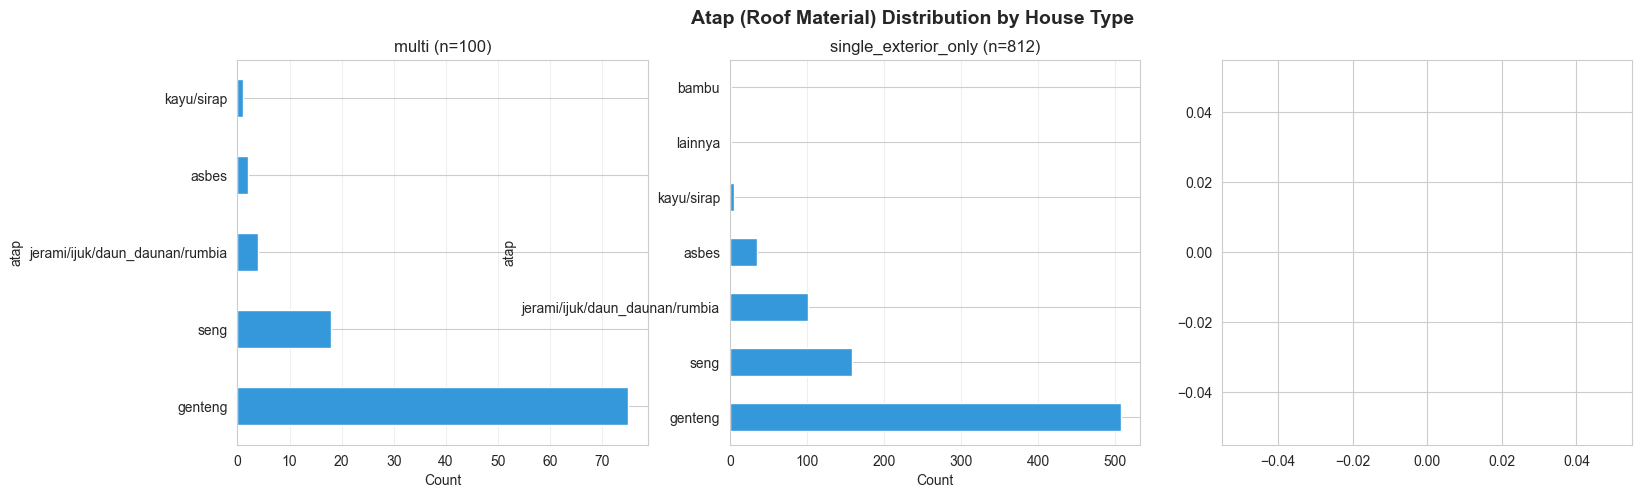

In [3]:
print("\n" + "="*80)
print("ATAP (ROOF MATERIAL) DISTRIBUTION")
print("="*80)

# Overall distribution
print("\n>>> OVERALL ATAP DISTRIBUTION (All House Types)")
print("-" * 60)
atap_overall = df_records["atap"].value_counts(dropna=True)
atap_overall_table = pd.DataFrame({
    "Material": atap_overall.index,
    "Count": atap_overall.values,
    "Percentage": (atap_overall.values / len(df_records) * 100).round(2)
})
print(atap_overall_table.to_string(index=False))

# Per house type breakdown
print("\n>>> ATAP DISTRIBUTION PER HOUSE TYPE")
print("-" * 60)

house_types = ["multi", "single_exterior_only", "single_interior_only"]
atap_by_type = {}

for ht in house_types:
    subset = df_records[df_records["inferred_house_type"] == ht]
    atap_counts = subset["atap"].value_counts(dropna=True)
    
    print(f"\n{ht.upper()} (n={len(subset)})")
    print("-" * 40)
    
    atap_table = pd.DataFrame({
        "Material": atap_counts.index,
        "Count": atap_counts.values,
        "Percentage": (atap_counts.values / len(subset) * 100).round(2)
    })
    print(atap_table.to_string(index=False))
    
    atap_by_type[ht] = atap_counts

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Atap (Roof Material) Distribution by House Type", fontsize=14, fontweight='bold')

for idx, (ht, ax) in enumerate(zip(house_types, axes)):
    counts = atap_by_type[ht]
    counts.plot(kind="barh", ax=ax, color='#3498db')
    ax.set_title(f"{ht} (n={len(df_records[df_records['inferred_house_type'] == ht])})")
    ax.set_xlabel("Count")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Section 3: Analyze Wall Material (Dinding) Distribution


DINDING (WALL MATERIAL) DISTRIBUTION

>>> OVERALL DINDING DISTRIBUTION (All House Types)
------------------------------------------------------------
                        Material  Count  Percentage
                          tembok    662       55.40
kayu/papan/gypsum/GRC/calciboard    304       25.44
                   anyaman_bambu    194       16.23
                           bambu     18        1.51
                         lainnya     11        0.92
                     batang_kayu      6        0.50

>>> DINDING DISTRIBUTION PER HOUSE TYPE
------------------------------------------------------------

MULTI (n=100)
----------------------------------------
                        Material  Count  Percentage
                          tembok     66        66.0
kayu/papan/gypsum/GRC/calciboard     21        21.0
                   anyaman_bambu     12        12.0
                         lainnya      1         1.0

SINGLE_EXTERIOR_ONLY (n=812)
-------------------------------------

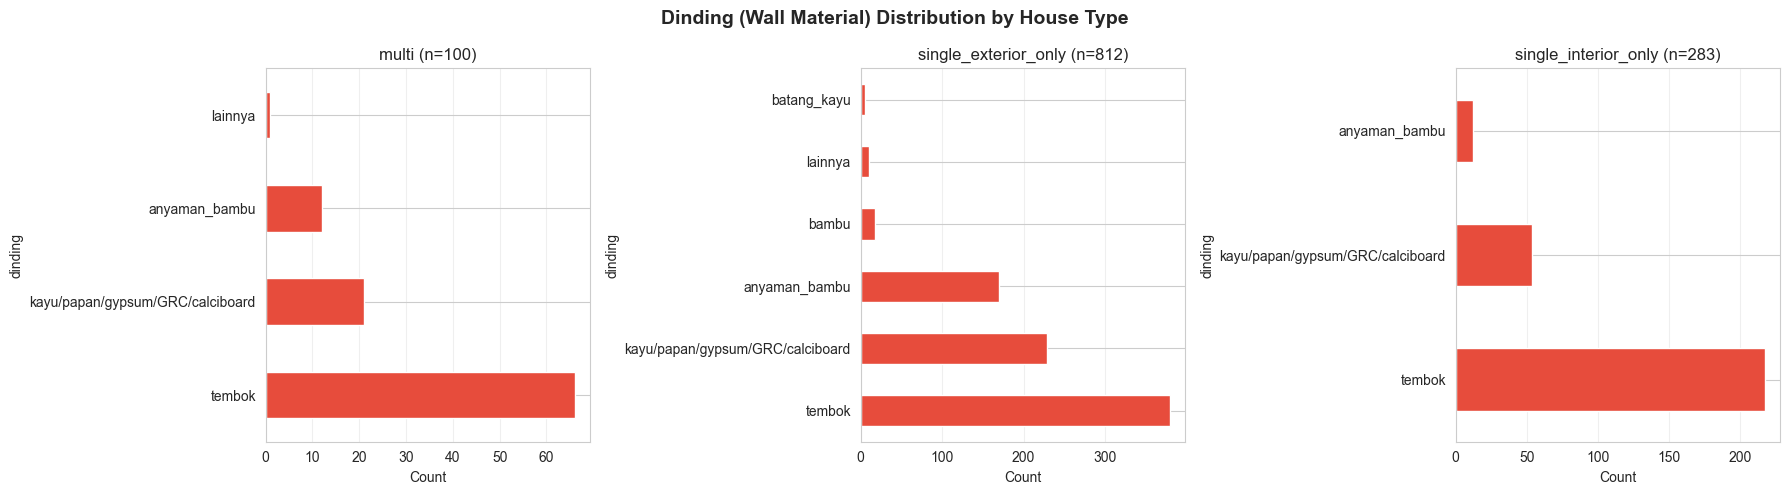

In [4]:
print("\n" + "="*80)
print("DINDING (WALL MATERIAL) DISTRIBUTION")
print("="*80)

# Overall distribution
print("\n>>> OVERALL DINDING DISTRIBUTION (All House Types)")
print("-" * 60)
dinding_overall = df_records["dinding"].value_counts(dropna=True)
dinding_overall_table = pd.DataFrame({
    "Material": dinding_overall.index,
    "Count": dinding_overall.values,
    "Percentage": (dinding_overall.values / len(df_records) * 100).round(2)
})
print(dinding_overall_table.to_string(index=False))

# Per house type breakdown
print("\n>>> DINDING DISTRIBUTION PER HOUSE TYPE")
print("-" * 60)

dinding_by_type = {}

for ht in house_types:
    subset = df_records[df_records["inferred_house_type"] == ht]
    dinding_counts = subset["dinding"].value_counts(dropna=True)
    
    print(f"\n{ht.upper()} (n={len(subset)})")
    print("-" * 40)
    
    dinding_table = pd.DataFrame({
        "Material": dinding_counts.index,
        "Count": dinding_counts.values,
        "Percentage": (dinding_counts.values / len(subset) * 100).round(2)
    })
    print(dinding_table.to_string(index=False))
    
    dinding_by_type[ht] = dinding_counts

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Dinding (Wall Material) Distribution by House Type", fontsize=14, fontweight='bold')

for idx, (ht, ax) in enumerate(zip(house_types, axes)):
    counts = dinding_by_type[ht]
    counts.plot(kind="barh", ax=ax, color='#e74c3c')
    ax.set_title(f"{ht} (n={len(df_records[df_records['inferred_house_type'] == ht])})")
    ax.set_xlabel("Count")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Section 4: Analyze Floor Material (Lantai) Distribution


LANTAI (FLOOR MATERIAL) DISTRIBUTION

>>> OVERALL LANTAI DISTRIBUTION (All House Types)
------------------------------------------------------------
           Material  Count  Percentage
            keramik    145       12.13
parket/vinil/karpet     80        6.69
      marmer/granit     44        3.68
         kayu/papan     42        3.51
   semen/bata_merah     28        2.34
              tanah     24        2.01
  ubin/tegel/teraso     18        1.51
              bambu      2        0.17

>>> LANTAI DISTRIBUTION PER HOUSE TYPE
------------------------------------------------------------

MULTI (n=100)
----------------------------------------
           Material  Count  Percentage
            keramik     39        39.0
         kayu/papan     18        18.0
parket/vinil/karpet     14        14.0
              tanah     12        12.0
   semen/bata_merah      8         8.0
      marmer/granit      5         5.0
  ubin/tegel/teraso      3         3.0
              bambu      1    

IndexError: index 0 is out of bounds for axis 0 with size 0

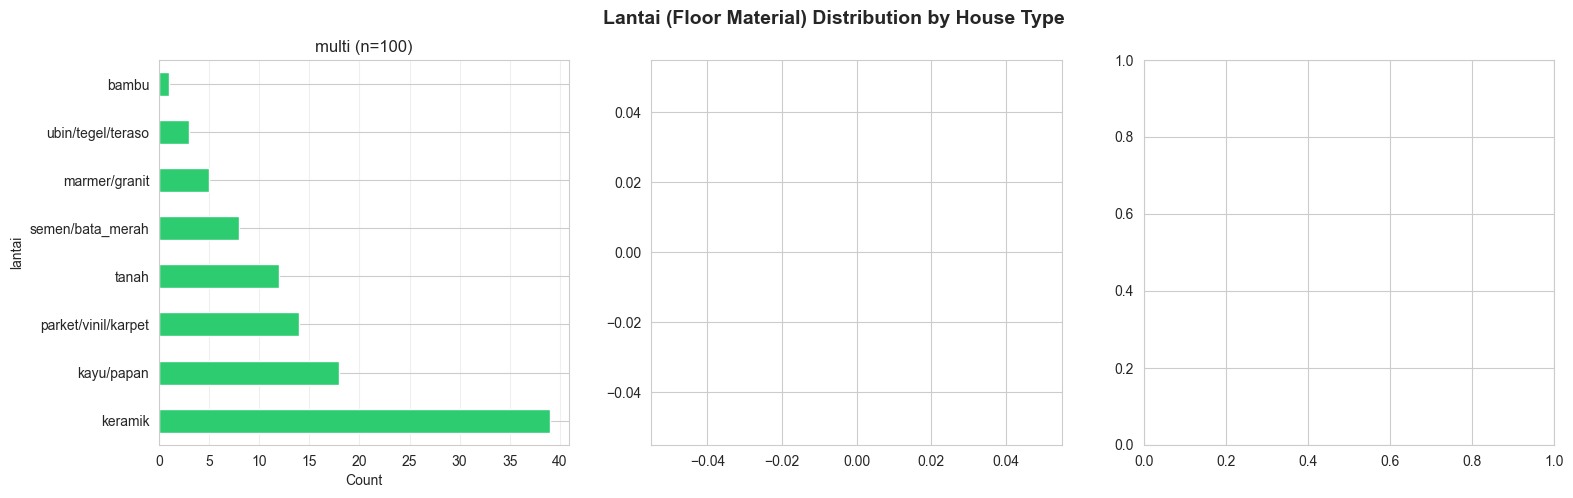

In [5]:
print("\n" + "="*80)
print("LANTAI (FLOOR MATERIAL) DISTRIBUTION")
print("="*80)

# Overall distribution
print("\n>>> OVERALL LANTAI DISTRIBUTION (All House Types)")
print("-" * 60)
lantai_overall = df_records["lantai"].value_counts(dropna=True)
lantai_overall_table = pd.DataFrame({
    "Material": lantai_overall.index,
    "Count": lantai_overall.values,
    "Percentage": (lantai_overall.values / len(df_records) * 100).round(2)
})
print(lantai_overall_table.to_string(index=False))

# Per house type breakdown
print("\n>>> LANTAI DISTRIBUTION PER HOUSE TYPE")
print("-" * 60)

lantai_by_type = {}

for ht in house_types:
    subset = df_records[df_records["inferred_house_type"] == ht]
    lantai_counts = subset["lantai"].value_counts(dropna=True)
    
    print(f"\n{ht.upper()} (n={len(subset)})")
    print("-" * 40)
    
    lantai_table = pd.DataFrame({
        "Material": lantai_counts.index,
        "Count": lantai_counts.values,
        "Percentage": (lantai_counts.values / len(subset) * 100).round(2)
    })
    print(lantai_table.to_string(index=False))
    
    lantai_by_type[ht] = lantai_counts

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Lantai (Floor Material) Distribution by House Type", fontsize=14, fontweight='bold')

for idx, (ht, ax) in enumerate(zip(house_types, axes)):
    counts = lantai_by_type[ht]
    counts.plot(kind="barh", ax=ax, color='#2ecc71')
    ax.set_title(f"{ht} (n={len(df_records[df_records['inferred_house_type'] == ht])})")
    ax.set_xlabel("Count")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Section 5: Compare Material Distribution by House Type (Cross-Tabulation)


CROSS-TABULATION: MATERIAL BY HOUSE TYPE

>>> ATAP by House Type
------------------------------------------------------------
atap                  asbes  bambu  genteng  jerami/ijuk/daun_daunan/rumbia  \
inferred_house_type                                                           
multi                     2      0       75                               4   
single_exterior_only     35      1      507                             102   
single_interior_only      0      0        0                               0   

atap                  kayu/sirap  lainnya  seng  NaN  
inferred_house_type                                   
multi                          1        0    18    0  
single_exterior_only           6        2   159    0  
single_interior_only           0        0     0  283  

Percentages (per House Type):
atap                  asbes  bambu  genteng  jerami/ijuk/daun_daunan/rumbia  \
inferred_house_type                                                           
multi        

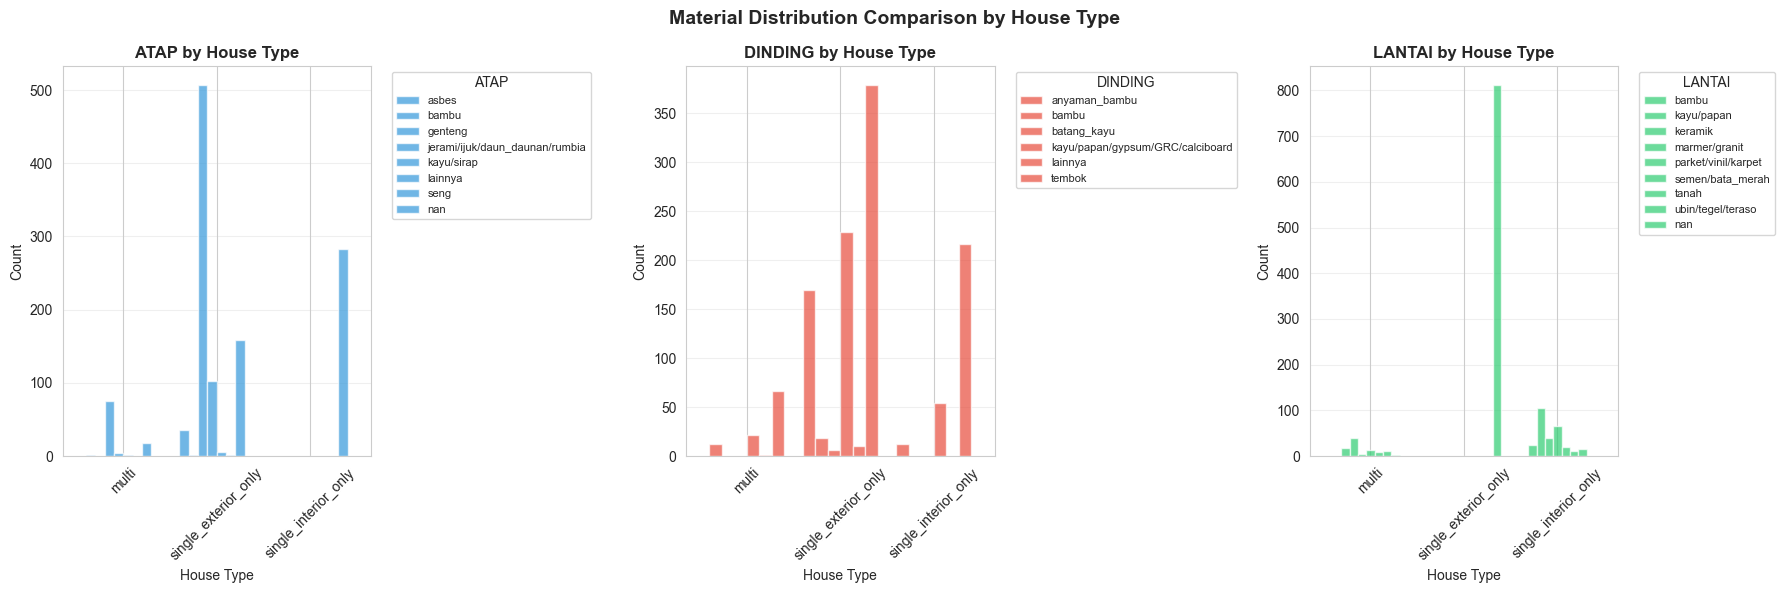

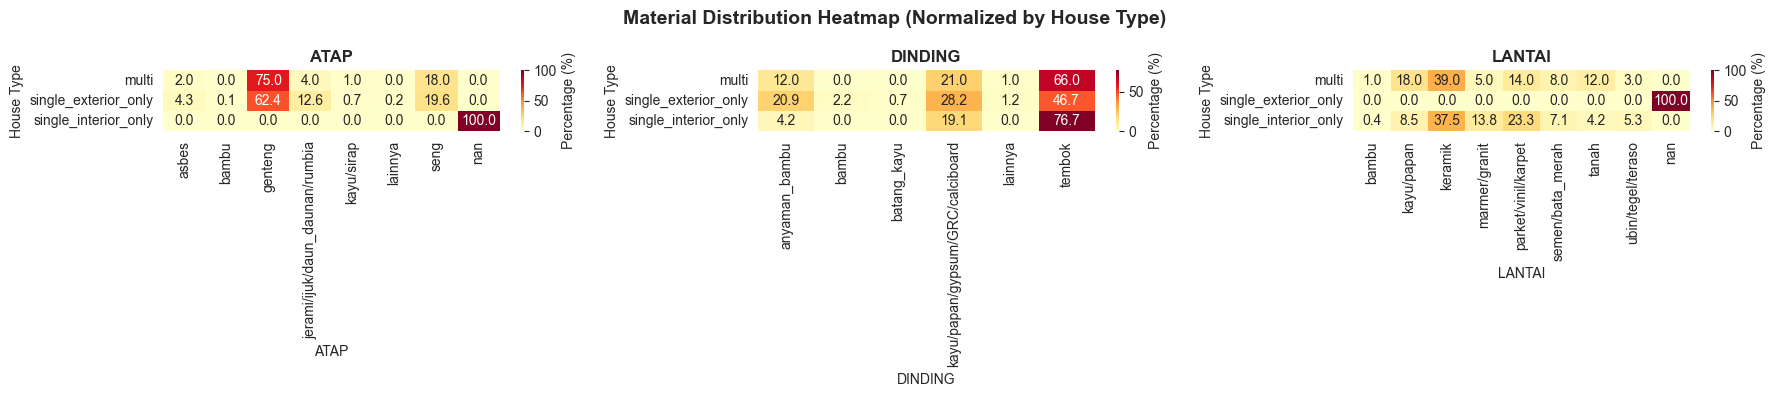

In [6]:
print("\n" + "="*80)
print("CROSS-TABULATION: MATERIAL BY HOUSE TYPE")
print("="*80)

# Create cross-tabulation for each material
for material in ["atap", "dinding", "lantai"]:
    print(f"\n>>> {material.upper()} by House Type")
    print("-" * 60)
    
    # Create cross tab
    crosstab = pd.crosstab(
        df_records["inferred_house_type"],
        df_records[material],
        margins=False,
        dropna=False
    )
    print(crosstab)
    
    # With percentages
    print(f"\nPercentages (per House Type):")
    crosstab_pct = pd.crosstab(
        df_records["inferred_house_type"],
        df_records[material],
        normalize='index',
        dropna=False
    ) * 100
    print(crosstab_pct.round(2))

# Visualization: grouped bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Material Distribution Comparison by House Type", fontsize=14, fontweight='bold')

materials = ["atap", "dinding", "lantai"]
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (material, ax, color) in enumerate(zip(materials, axes, colors)):
    crosstab = pd.crosstab(
        df_records["inferred_house_type"],
        df_records[material],
        dropna=False
    )
    
    crosstab.plot(kind="bar", ax=ax, color=color, alpha=0.7, width=0.8)
    ax.set_title(f"{material.upper()} by House Type", fontweight='bold')
    ax.set_xlabel("House Type")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title=material.upper(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Heatmap visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Material Distribution Heatmap (Normalized by House Type)", fontsize=14, fontweight='bold')

for idx, (material, ax) in enumerate(zip(materials, axes)):
    crosstab_norm = pd.crosstab(
        df_records["inferred_house_type"],
        df_records[material],
        normalize='index',
        dropna=False
    ) * 100
    
    sns.heatmap(crosstab_norm, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=ax, cbar_kws={'label': 'Percentage (%)'})
    ax.set_title(f"{material.upper()}", fontweight='bold')
    ax.set_ylabel("House Type")
    ax.set_xlabel(material.upper())

plt.tight_layout()
plt.show()
